# SENTIMENT ANALYSIS
## Social Media & News Sentiment Data
## Source: Alpha Vantage News Sentiment API (Free)

## Section 1: Install required libraries

In [15]:

# Install and Import Libraries


import requests
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.patches import Patch
from vaderSentiment.vaderSentiment import (
    SentimentIntensityAnalyzer
)
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


## Section 2: Configuration and API Setup

In [16]:
# Configuration
# We paste our free Alpha Vantage API key below
# Gotten from: https://www.alphavantage.co/support/#api-key

API_KEY = "YOUY9JK4KJ0FCA1U5A0"
TICKERS = ["IVV", "SPY", "QQQ"]
BASE_URL = "https://www.alphavantage.co/query"

print(f"Configuration set.")
print(f"Tickers: {TICKERS}")

Configuration set.
Tickers: ['IVV', 'SPY', 'QQQ']


## SECTION 3: Fetch News and Sentiment Data

In [17]:
def fetch_news_sentiment(ticker, api_key, limit=50):
    """
    Fetches real news articles and sentiment scores
    from Alpha Vantage for a given ticker.
    Returns a clean pandas DataFrame.
    """
    params = {
        "function"  : "NEWS_SENTIMENT",
        "tickers"   : ticker,
        "limit"     : limit,
        "apikey"    : api_key,
        "sort"      : "LATEST"
    }

    try:
        resp = requests.get(
            BASE_URL, params=params, timeout=15
        )
        resp.raise_for_status()
        data = resp.json()

        # Check for API error messages
        if "Information" in data:
            print(f"API limit reached: {data['Information']}")
            return pd.DataFrame()

        if "feed" not in data:
            print(f"No feed data for {ticker}")
            print(f"Response: {data}")
            return pd.DataFrame()

        articles = data["feed"]
        rows     = []

        for article in articles:
            # Extract ticker-specific sentiment
            ticker_sentiment = None
            ticker_relevance = None

            for ts in article.get(
                    "ticker_sentiment", []):
                if ts.get("ticker") == ticker:
                    ticker_sentiment = float(
                        ts.get(
                            "ticker_sentiment_score", 0
                        )
                    )
                    ticker_relevance = float(
                        ts.get("relevance_score", 0)
                    )
                    break

            rows.append({
                "ticker"           : ticker,
                "title"            : article.get(
                                         "title", ""),
                "summary"          : article.get(
                                         "summary", ""),
                "source"           : article.get(
                                         "source", ""),
                "url"              : article.get(
                                         "url", ""),
                "published"        : article.get(
                                         "time_published",
                                         ""),
                "overall_sentiment": article.get(
                    "overall_sentiment_score", 0),
                "overall_label"    : article.get(
                    "overall_sentiment_label", ""),
                "ticker_sentiment" : ticker_sentiment,
                "ticker_relevance" : ticker_relevance,
                "topics"           : ", ".join([
                    t.get("topic", "")
                    for t in article.get("topics", [])
                ])
            })

        df = pd.DataFrame(rows)

        # Parse date
        df["published"] = pd.to_datetime(
            df["published"],
            format="%Y%m%dT%H%M%S",
            errors="coerce"
        )
        df["date"] = df["published"].dt.date

        print(f"Fetched {len(df)} articles for {ticker}")
        return df

    except Exception as e:
        print(f"Error fetching {ticker}: {e}")
        return pd.DataFrame()


# --- Collect data for all tickers ---
print("=" * 55)
print("FETCHING NEWS SENTIMENT DATA")
print("=" * 55)

frames = []
for ticker in TICKERS:
    df_ticker = fetch_news_sentiment(
        ticker, API_KEY, limit=50
    )
    if not df_ticker.empty:
        frames.append(df_ticker)

if not frames:
    print("\nNo data fetched. Check your API key.")
else:
    master_df = pd.concat(frames, ignore_index=True)
    master_df.sort_values("published", inplace=True)
    master_df.reset_index(drop=True, inplace=True)

    print(f"\nTotal articles collected: {len(master_df)}")
    print("\nSample data:")
    print(master_df[[
        "ticker", "title",
        "overall_sentiment",
        "overall_label",
        "ticker_sentiment"
    ]].head(10))

FETCHING NEWS SENTIMENT DATA
Fetched 50 articles for IVV
Fetched 50 articles for SPY
Fetched 50 articles for QQQ

Total articles collected: 150

Sample data:
  ticker                                              title  \
0    IVV  Should You Buy the iShares S&P 500 ETF Before ...   
1    IVV  Should You Buy the iShares S&P 500 ETF Before ...   
2    IVV                                IVV ETF Closes Flat   
3    IVV  Should iShares Core S&P 500 ETF (IVV) Be on Yo...   
4    IVV  Why the IVV ETF and these funds could be top b...   
5    IVV  Should iShares Core S&P 500 ETF (IVV) Be on Yo...   
6    IVV  Should You Buy the iShares S&P 500 ETF Before ...   
7    IVV  What Is IVV? How to Invest in the iShares Core...   
8    IVV  Capital Investment Advisors, LLC's iShares Cor...   
9    IVV  Tudor Investment adds Alphabet, exits Meta, bo...   

   overall_sentiment     overall_label  ticker_sentiment  
0           0.335993  Somewhat-Bullish          0.491127  
1           0.289067  Somewhat

## SECTION 4: Additional Sentiment Scoring with VADER


In [18]:
analyzer = SentimentIntensityAnalyzer()

def vader_score(text):
    """Returns VADER compound score for a text string."""
    if pd.isna(text) or str(text).strip() == "":
        return 0.0
    scores = analyzer.polarity_scores(str(text))
    return round(scores["compound"], 4)

def vader_label(score):
    """Converts VADER compound score to a label."""
    if score >= 0.05:
        return "Bullish"
    elif score <= -0.05:
        return "Bearish"
    else:
        return "Neutral"

# Apply VADER to article titles and summaries
master_df["vader_title"] = master_df[
    "title"].apply(vader_score)
master_df["vader_summary"] = master_df[
    "summary"].apply(vader_score)

# Combined VADER score (weighted average)
master_df["vader_combined"] = (
    master_df["vader_title"] * 0.4 +
    master_df["vader_summary"] * 0.6
).round(4)

master_df["vader_label"] = master_df[
    "vader_combined"].apply(vader_label)

print("\n" + "=" * 55)
print("VADER SENTIMENT SCORING COMPLETE")
print("=" * 55)
print(master_df[[
    "ticker", "title",
    "vader_combined", "vader_label",
    "overall_label"
]].head(8))


VADER SENTIMENT SCORING COMPLETE
  ticker                                              title  vader_combined  \
0    IVV  Should You Buy the iShares S&P 500 ETF Before ...          0.5316   
1    IVV  Should You Buy the iShares S&P 500 ETF Before ...         -0.1639   
2    IVV                                IVV ETF Closes Flat          0.2924   
3    IVV  Should iShares Core S&P 500 ETF (IVV) Be on Yo...          0.4876   
4    IVV  Why the IVV ETF and these funds could be top b...          0.4241   
5    IVV  Should iShares Core S&P 500 ETF (IVV) Be on Yo...          0.3749   
6    IVV  Should You Buy the iShares S&P 500 ETF Before ...          0.0616   
7    IVV  What Is IVV? How to Invest in the iShares Core...          0.1067   

  vader_label     overall_label  
0     Bullish  Somewhat-Bullish  
1     Bearish  Somewhat-Bullish  
2     Bullish           Neutral  
3     Bullish  Somewhat-Bullish  
4     Bullish  Somewhat-Bullish  
5     Bullish  Somewhat-Bullish  
6     Bullish  S

## SECTION 5: Summary Statistics

In [19]:
print("\n" + "=" * 55)
print("DESCRIPTIVE STATISTICS")
print("=" * 55)
print(master_df[[
    "overall_sentiment",
    "ticker_sentiment",
    "vader_combined",
    "ticker_relevance"
]].describe().round(3))

print("\nAlpha Vantage Label Distribution:")
print(master_df["overall_label"].value_counts())

print("\nVADER Label Distribution:")
print(master_df["vader_label"].value_counts())

print("\nSentiment by Ticker:")
print(pd.crosstab(
    master_df["ticker"],
    master_df["vader_label"],
    margins=True
))

print("\nTop News Sources:")
print(master_df["source"].value_counts().head(10))


DESCRIPTIVE STATISTICS
       overall_sentiment  ticker_sentiment  vader_combined  ticker_relevance
count            150.000           150.000         150.000           150.000
mean               0.126             0.122           0.303             0.832
std                0.214             0.258           0.345             0.289
min               -0.398            -0.484          -0.880             0.301
25%                0.021             0.004           0.121             0.830
50%                0.080             0.049           0.382             1.000
75%                0.304             0.340           0.551             1.000
max                0.712             0.735           0.882             1.000

Alpha Vantage Label Distribution:
overall_label
Neutral             75
Somewhat-Bullish    38
Bullish             22
Somewhat-Bearish    12
Bearish              3
Name: count, dtype: int64

VADER Label Distribution:
vader_label
Bullish    119
Bearish     18
Neutral     13
Name: cou

## SECTION 6: Exploratory Data Analysis — All Plots

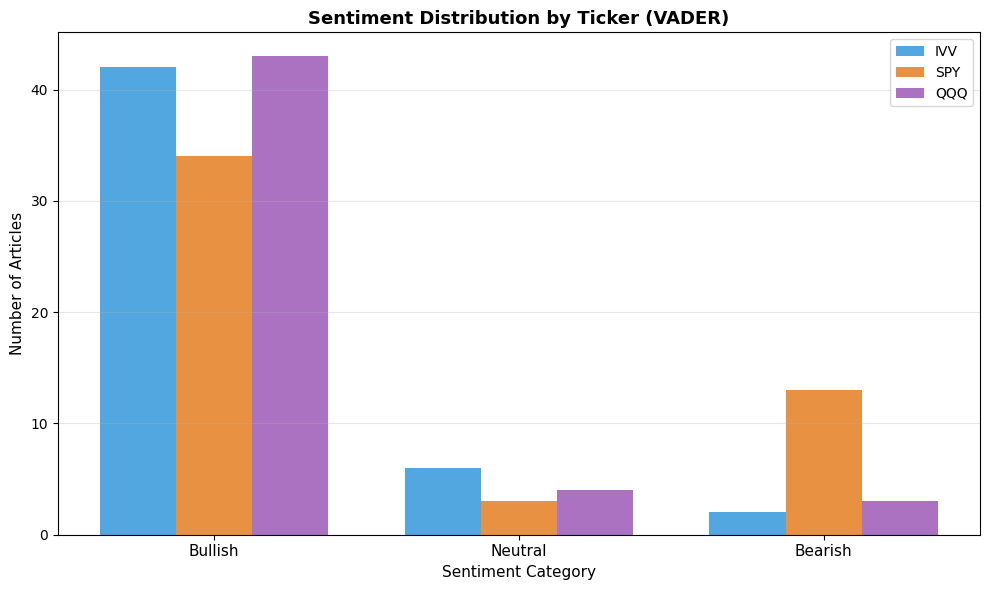

Saved: plot1_sentiment_distribution.png


In [20]:
# Plot 1 — Sentiment Distribution by Ticker
ticker_colors   = {
    "IVV": "#3498db",
    "SPY": "#e67e22",
    "QQQ": "#9b59b6"
}
sentiment_order = ["Bullish", "Neutral", "Bearish"]

x     = np.arange(len(sentiment_order))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, ticker in enumerate(TICKERS):
    subset = master_df[
        master_df["ticker"] == ticker
    ]
    counts = subset["vader_label"].value_counts()
    counts = counts.reindex(
        sentiment_order, fill_value=0
    )
    ax.bar(
        x + i * width,
        counts.values,
        width,
        label=ticker,
        color=ticker_colors[ticker],
        alpha=0.85
    )

ax.set_title(
    "Sentiment Distribution by Ticker (VADER)",
    fontsize=13, fontweight="bold"
)
ax.set_xticks(x + width)
ax.set_xticklabels(sentiment_order, fontsize=11)
ax.set_ylabel("Number of Articles", fontsize=11)
ax.set_xlabel("Sentiment Category", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(
    "plot1_sentiment_distribution.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved: plot1_sentiment_distribution.png")

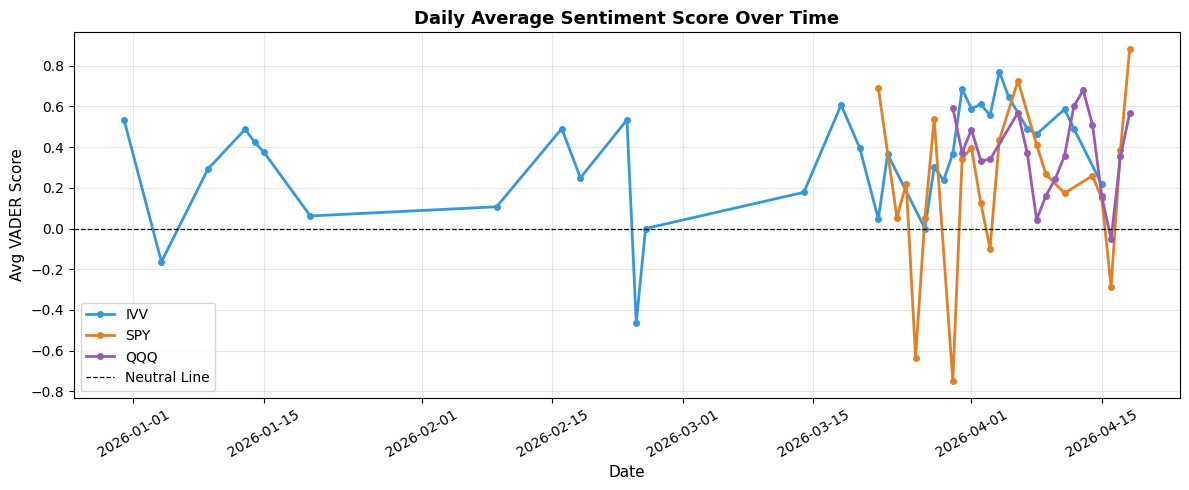

Saved: plot2_sentiment_over_time.png


In [21]:
# Plot 2 — Daily Average Sentiment Over Time


fig, ax = plt.subplots(figsize=(12, 5))

for ticker in TICKERS:
    subset = master_df[
        master_df["ticker"] == ticker
    ].copy()
    subset = subset.set_index(
        "published"
    )["vader_combined"]

    if len(subset) > 3:
        daily = subset.resample("D").mean().dropna()
        ax.plot(
            daily.index,
            daily.values,
            color=ticker_colors[ticker],
            linewidth=2,
            label=ticker,
            marker="o",
            markersize=4
        )

ax.axhline(
    y=0, color="black",
    linestyle="--", linewidth=0.9,
    label="Neutral Line"
)
ax.set_title(
    "Daily Average Sentiment Score Over Time",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Avg VADER Score", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.setp(
    ax.xaxis.get_majorticklabels(), rotation=30
)

plt.tight_layout()
plt.savefig(
    "plot2_sentiment_over_time.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved: plot2_sentiment_over_time.png")

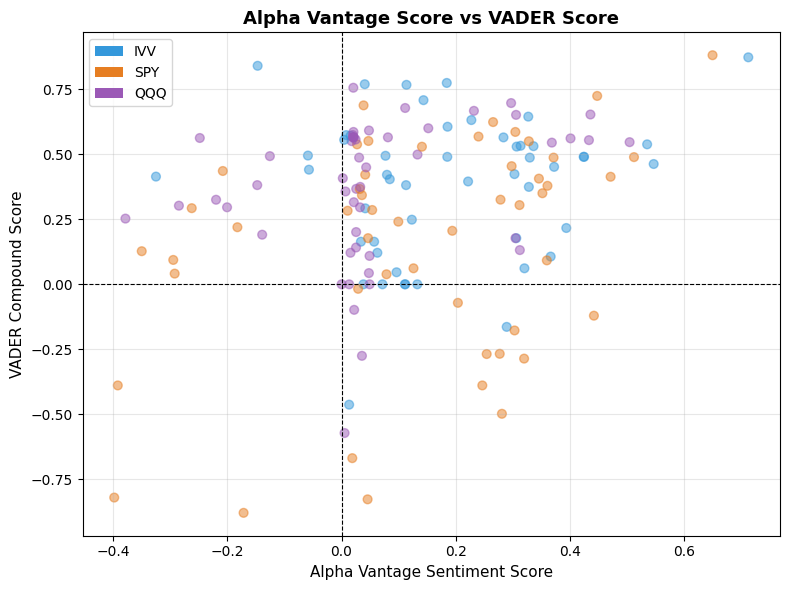

Saved: plot3_av_vs_vader_scatter.png


In [22]:
# Plot 3 — Alpha Vantage vs VADER Score Scatter

fig, ax = plt.subplots(figsize=(8, 6))

scatter_colors = [
    ticker_colors.get(t, "#3498db")
    for t in master_df["ticker"]
]

ax.scatter(
    master_df["overall_sentiment"],
    master_df["vader_combined"],
    alpha=0.5, s=40,
    c=scatter_colors
)
ax.axhline(
    y=0, color="black",
    linestyle="--", linewidth=0.8
)
ax.axvline(
    x=0, color="black",
    linestyle="--", linewidth=0.8
)
ax.set_title(
    "Alpha Vantage Score vs VADER Score",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel(
    "Alpha Vantage Sentiment Score",
    fontsize=11
)
ax.set_ylabel("VADER Compound Score", fontsize=11)
ax.grid(True, alpha=0.3)

legend_elements = [
    Patch(facecolor=ticker_colors[t], label=t)
    for t in TICKERS
]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig(
    "plot3_av_vs_vader_scatter.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved: plot3_av_vs_vader_scatter.png")

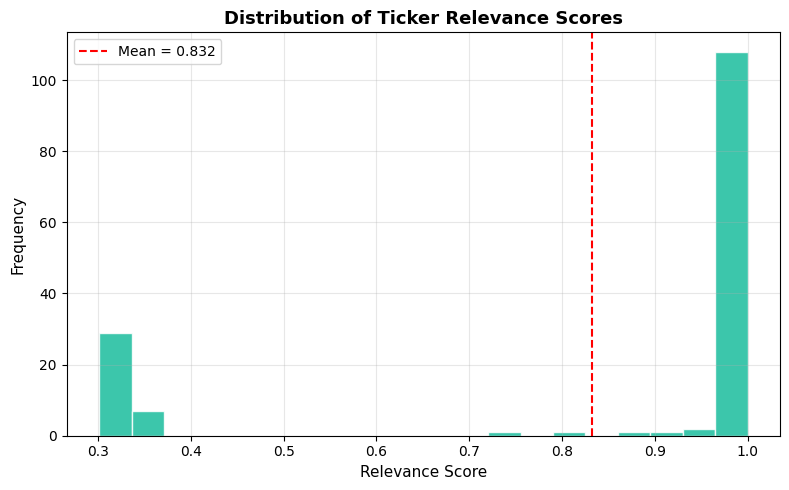

Saved: plot4_relevance_distribution.png


In [23]:
# Plot 4 — Relevance Score Distribution

fig, ax = plt.subplots(figsize=(8, 5))

rel_data = master_df["ticker_relevance"].dropna()
mean_rel = rel_data.mean()

ax.hist(
    rel_data, bins=20,
    color="#1abc9c",
    edgecolor="white", alpha=0.85
)
ax.axvline(
    x=mean_rel, color="red",
    linestyle="--", linewidth=1.5,
    label=f"Mean = {mean_rel:.3f}"
)
ax.set_title(
    "Distribution of Ticker Relevance Scores",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Relevance Score", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "plot4_relevance_distribution.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved: plot4_relevance_distribution.png")

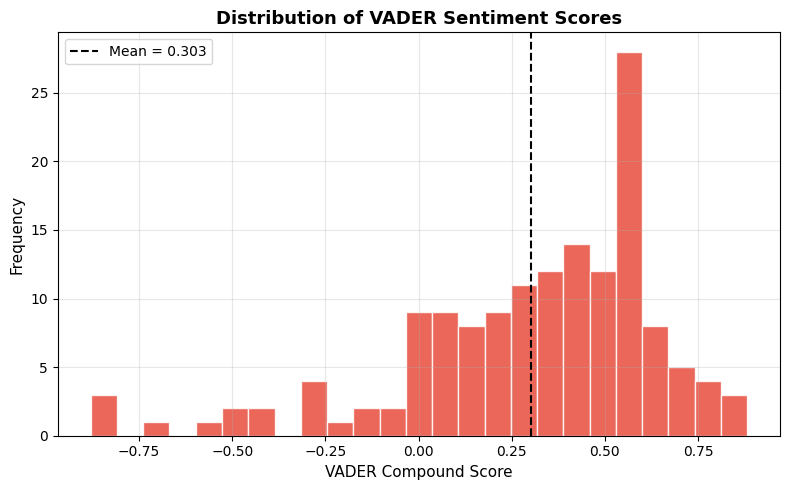

Saved: plot5_vader_distribution.png


In [24]:
# Plot 5 — VADER Score Distribution

fig, ax = plt.subplots(figsize=(8, 5))

mean_vader = master_df["vader_combined"].mean()

ax.hist(
    master_df["vader_combined"],
    bins=25, color="#e74c3c",
    edgecolor="white", alpha=0.85
)
ax.axvline(
    x=mean_vader, color="black",
    linestyle="--", linewidth=1.5,
    label=f"Mean = {mean_vader:.3f}"
)
ax.set_title(
    "Distribution of VADER Sentiment Scores",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("VADER Compound Score", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "plot5_vader_distribution.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved: plot5_vader_distribution.png")

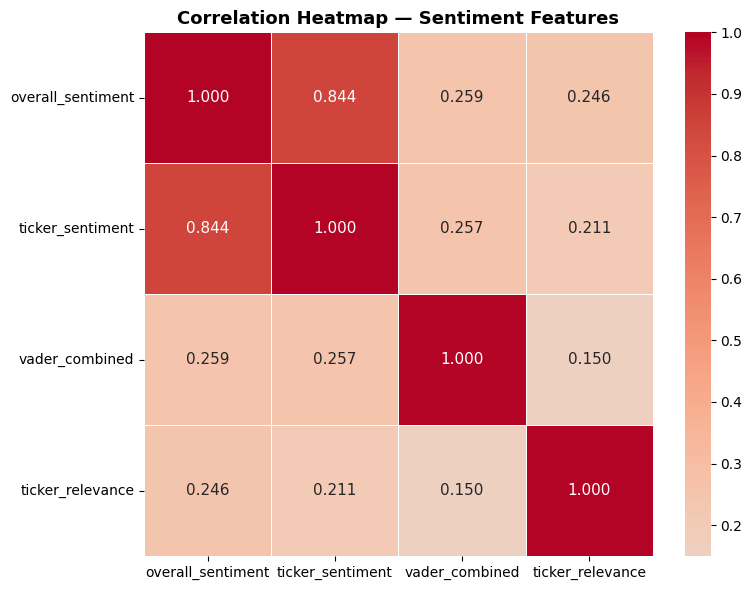

Saved: plot6_correlation_heatmap.png

CORRELATION MATRIX
                   overall_sentiment  ticker_sentiment  vader_combined  \
overall_sentiment              1.000             0.844           0.259   
ticker_sentiment               0.844             1.000           0.257   
vader_combined                 0.259             0.257           1.000   
ticker_relevance               0.246             0.211           0.150   

                   ticker_relevance  
overall_sentiment             0.246  
ticker_sentiment              0.211  
vader_combined                0.150  
ticker_relevance              1.000  

All analysis complete.


In [25]:
# Plot 6 — Correlation Heatmap

fig, ax = plt.subplots(figsize=(8, 6))

corr_cols = [
    "overall_sentiment",
    "ticker_sentiment",
    "vader_combined",
    "ticker_relevance"
]
corr_matrix = master_df[corr_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True, fmt=".3f",
    cmap="coolwarm", center=0,
    ax=ax, linewidths=0.5,
    annot_kws={"size": 11}
)
ax.set_title(
    "Correlation Heatmap — Sentiment Features",
    fontsize=13, fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    "plot6_correlation_heatmap.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved: plot6_correlation_heatmap.png")

print("\n" + "=" * 50)
print("CORRELATION MATRIX")
print("=" * 50)
print(corr_matrix.round(3))
print("\nAll analysis complete.")